### 0. Install Library Tambahan

In [ ]:
!pip install pmdarima scikit-learn tqdm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.6 MB/s eta 0:00:00


### 1. Mount Drive & Load Dataset Hasil Preprocessing

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/PetaKeheningan'
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
PANEL_PATH = os.path.join(OUTPUT_DIR, 'panel_data_clean.csv')

import pandas as pd

df_panel = pd.read_csv(PANEL_PATH)
df_panel = df_panel.sort_values(['iso3', 'year']).reset_index(drop=True)

print("✅ Dataset panel berhasil dimuat")
print(f"   Path    : {PANEL_PATH}")
print(f"   Shape   : {df_panel.shape}")
print(f"   Negara  : {df_panel['iso3'].nunique()}")
print(f"   Tahun   : {df_panel['year'].min()}–{df_panel['year'].max()}")
print()
print(df_panel.head(3))


Mounted at /content/drive
✅ Dataset panel berhasil dimuat
   Path    : /content/drive/MyDrive/PetaKeheningan/output/panel_data_clean.csv
   Shape   : (5365, 12)
   Negara  : 185
   Tahun   : 1997–2025

  iso3  year      country  pct_women  pct_women_wb quota_type  pct_women_raw  \
0  AFG  1997  Afghanistan      27.31           NaN   No Quota            NaN   
1  AFG  1998  Afghanistan      27.31           NaN   No Quota            NaN   
2  AFG  1999  Afghanistan      27.31           NaN   No Quota            NaN   

   delta_pct  reached_parity  milestone_30pct  milestone_50pct        region  
0        NaN           False              NaN              NaN  Asia-Pasifik  
1        0.0           False              NaN              NaN  Asia-Pasifik  
2        0.0           False              NaN              NaN  Asia-Pasifik  


### 2. Import Library Forecasting

In [ ]:
import numpy as np
import warnings
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✅ Library forecasting berhasil diimport")


✅ Library forecasting berhasil diimport


### 3. Parameter Pipeline

In [ ]:
TEST_YEARS      = 5        # tahun terakhir dipakai sebagai test set (2021–2025)
PARITY_TARGET   = 50.0     # ambang paritas gender
MAX_HORIZON     = 250      # batas maksimum tahun forecast ke depan (anti infinite loop)
CAP_YEAR_GREEN  = 2063     # hijau: paritas tercapai sebelum tahun ini
CAP_YEAR_ORANGE = 2100     # oranye: 2063–2100, merah: setelah 2100 / tidak konvergen

print(f"Target paritas      : {PARITY_TARGET}%")
print(f"Test set evaluasi   : {TEST_YEARS} tahun terakhir (2021–2025)")
print(f"Horizon maksimum    : {MAX_HORIZON} tahun ke depan")
print(f"Ambang warna        : hijau < {CAP_YEAR_GREEN} | oranye ≤ {CAP_YEAR_ORANGE} | merah > {CAP_YEAR_ORANGE}")


Target paritas      : 50.0%
Test set evaluasi   : 5 tahun terakhir (2021–2025)
Horizon maksimum    : 250 tahun ke depan
Ambang warna        : hijau < 2063 | oranye ≤ 2100 | merah > 2100


### 4. Fungsi Inti — Fit, Evaluasi, dan Forecast per Negara

Untuk setiap negara, fungsi ini melakukan tiga hal:
1. **Evaluasi**: latih di 1997–2020, uji di 2021–2025 → hitung RMSE & MAE
2. **Refit penuh**: latih ulang di seluruh data 1997–2025 untuk forecasting jangka panjang
3. **Cari tahun paritas**: forecast ke depan sampai `pct_women` ≥ 50%, lalu kategorikan warnanya

In [ ]:
def forecast_one_country(iso3_code, group):
    group  = group.sort_values('year').reset_index(drop=True)
    years  = group['year'].values
    series = group['pct_women'].values
    last_year  = int(years[-1])
    last_value = float(series[-1])

    result = {
        'iso3': iso3_code,
        'country': group['country'].iloc[0],
        'region': group['region'].iloc[0],
        'quota_type': group['quota_type'].iloc[0],
        'pct_2025': round(last_value, 2),
        'rmse': np.nan,
        'mae': np.nan,
        'model_order': None,
        'predicted_parity_year': None,
        'category': None,
        'note': ''
    }

    # Negara yang sudah mencapai paritas — tidak perlu forecasting
    if last_value >= PARITY_TARGET:
        already = group.loc[group['pct_women'] >= PARITY_TARGET, 'year']
        result['predicted_parity_year'] = int(already.min())
        result['category'] = 'putih'
        result['note'] = 'Sudah mencapai paritas'
        return result

    try:
        # ---- 1. Train/test split untuk evaluasi metrik ----
        train, test = series[:-TEST_YEARS], series[-TEST_YEARS:]
        model_eval = auto_arima(
            train, seasonal=False, suppress_warnings=True,
            error_action='ignore', stepwise=True,
            max_p=3, max_d=2, max_q=3
        )
        pred_test = model_eval.predict(n_periods=TEST_YEARS)
        result['rmse'] = round(float(np.sqrt(mean_squared_error(test, pred_test))), 3)
        result['mae']  = round(float(mean_absolute_error(test, pred_test)), 3)

        # ---- 2. Refit di seluruh data untuk forecasting jangka panjang ----
        model_full = auto_arima(
            series, seasonal=False, suppress_warnings=True,
            error_action='ignore', stepwise=True,
            max_p=3, max_d=2, max_q=3
        )
        result['model_order'] = str(model_full.order)

        forecast = model_full.predict(n_periods=MAX_HORIZON)
        forecast = np.clip(forecast, 0, 100)

        crossing = np.where(forecast >= PARITY_TARGET)[0]
        if len(crossing) > 0:
            result['predicted_parity_year'] = last_year + int(crossing[0]) + 1
        else:
            result['predicted_parity_year'] = None
            result['note'] = 'Tidak konvergen dalam horizon proyeksi'

    except Exception as e:
        # ---- Fallback: regresi linear sederhana jika ARIMA gagal ----
        slope, intercept = np.polyfit(years, series, 1)
        result['model_order'] = 'linear_fallback'
        if slope <= 0:
            result['note'] = f'ARIMA gagal ({type(e).__name__}); tren stagnan/menurun'
            result['predicted_parity_year'] = None
        else:
            result['predicted_parity_year'] = int((PARITY_TARGET - intercept) / slope)
            result['note'] = f'ARIMA gagal ({type(e).__name__}); fallback regresi linear'

    # ---- 3. Kategorisasi warna untuk layer choropleth ----
    py = result['predicted_parity_year']
    if py is None:
        result['category'] = 'merah'
    elif py < CAP_YEAR_GREEN:
        result['category'] = 'hijau'
    elif py <= CAP_YEAR_ORANGE:
        result['category'] = 'oranye'
    else:
        result['category'] = 'merah'

    return result

print("✅ Fungsi forecast_one_country() siap dipakai")


✅ Fungsi forecast_one_country() siap dipakai


### 5. Jalankan Pipeline untuk Seluruh Negara

⏱️ Estimasi waktu: sekitar 3–8 menit untuk 185 negara (tergantung resource Colab).

In [ ]:
results = []
failed  = []

for iso3_code, group in tqdm(df_panel.groupby('iso3'), desc='Forecasting per negara'):
    try:
        results.append(forecast_one_country(iso3_code, group))
    except Exception as e:
        failed.append((iso3_code, str(e)))

df_forecast = pd.DataFrame(results)

print(f"✅ Forecasting selesai untuk {len(df_forecast)} negara")
if failed:
    print(f"⚠️  {len(failed)} negara gagal total (tidak ter-cover fallback): {failed}")

df_forecast.head(10)


Forecasting per negara:   0%|          | 0/185 [00:00<?, ?it/s]

✅ Forecasting selesai untuk 185 negara


,iso3,country,region,quota_type,pct_2025,rmse,mae,model_order,predicted_parity_year,category,note
0,AFG,Afghanistan,Asia-Pasifik,No Quota,27.02,0.209,0.198,"(1, 0, 0)",NaN,merah,Tidak konvergen dalam horizon proyeksi
1,AGO,Angola,Afrika,Voluntary Party Quota,39.10,6.718,5.556,"(0, 1, 0)",NaN,merah,Tidak konvergen dalam horizon proyeksi
2,ALB,Albania,Eropa,Legislated Candidate Quota,35.00,2.782,2.455,"(0, 1, 0)",2040.0,hijau,
3,ARE,United Arab Emirates,MENA,Legislated Candidate Quota,50.00,NaN,NaN,None,2019.0,putih,Sudah mencapai paritas
4,ARG,Argentina,Amerika,Legislated Candidate Quota,41.30,2.556,2.263,"(0, 1, 0)",NaN,merah,Tidak konvergen dalam horizon proyeksi
5,ARM,Armenia,Afrika,Legislated Candidate Quota,38.30,11.034,11.017,"(0, 2, 0)",2032.0,hijau,
6,AUS,Australia,Asia-Pasifik,Voluntary Party Quota,46.00,6.507,5.491,"(0, 1, 0)",2029.0,hijau,
7,AUT,Austria,Eropa,Voluntary Party Quota,35.50,3.250,2.749,"(0, 1, 0)",NaN,merah,Tidak konvergen dalam horizon proyeksi
8,AZE,Azerbaijan,Afrika,No Quota,20.80,1.807,1.512,"(0, 1, 0)",NaN,merah,Tidak konvergen dalam horizon proyeksi
9,BDI,Burundi,Afrika,Legislated Candidate Quota,39.60,3.686,3.402,"(0, 1, 0)",2035.0,hijau,


### 6. Ringkasan & Validasi Hasil

In [ ]:
print("=" * 60)
print("📋 RINGKASAN HASIL FORECASTING")
print("=" * 60)

print("\nDistribusi kategori warna:")
print(df_forecast['category'].value_counts().to_string())

print(f"\nRMSE rata-rata global : {df_forecast['rmse'].mean():.3f} poin persentase")
print(f"MAE  rata-rata global : {df_forecast['mae'].mean():.3f} poin persentase")

print("\n5 negara dengan proyeksi paritas TERCEPAT (belum tercapai):")
fastest = (df_forecast[df_forecast['category'] != 'putih']
           .dropna(subset=['predicted_parity_year'])
           .nsmallest(5, 'predicted_parity_year')
           [['country', 'iso3', 'pct_2025', 'predicted_parity_year', 'rmse']])
print(fastest.to_string(index=False))

print("\n5 negara dengan model fit TERBAIK (RMSE terendah):")
best_fit = (df_forecast.dropna(subset=['rmse'])
            .nsmallest(5, 'rmse')[['country', 'iso3', 'rmse', 'mae', 'model_order']])
print(best_fit.to_string(index=False))

n_no_converge = (df_forecast['note'] == 'Tidak konvergen dalam horizon proyeksi').sum()
print(f"\n⚠️  Negara tidak konvergen dalam {MAX_HORIZON} tahun proyeksi: {n_no_converge}")


📋 RINGKASAN HASIL FORECASTING

Distribusi kategori warna:
category
merah     106
hijau      53
oranye     20
putih       6

RMSE rata-rata global : 4.098 poin persentase
MAE  rata-rata global : 3.613 poin persentase

5 negara dengan proyeksi paritas TERCEPAT (belum tercapai):
   country iso3  pct_2025  predicted_parity_year   rmse
Costa Rica  CRI      49.1                 2026.0  2.187
 Australia  AUS      46.0                 2029.0  6.507
   Ecuador  ECU      45.0                 2029.0  2.422
Cape Verde  CPV      44.4                 2030.0 12.837
  Ethiopia  ETH      41.9                 2031.0  3.118

5 negara dengan model fit TERBAIK (RMSE terendah):
     country iso3  rmse   mae model_order
  Bangladesh  BGD 0.000 0.000   (0, 1, 0)
     Myanmar  MMR 0.000 0.000   (0, 1, 0)
     Eritrea  ERI 0.005 0.005   (0, 0, 1)
 North Korea  PRK 0.008 0.006   (1, 0, 0)
Saudi Arabia  SAU 0.023 0.018   (0, 1, 0)

⚠️  Negara tidak konvergen dalam 250 tahun proyeksi: 100


### 7. Validasi Visual — Contoh dari Setiap Kategori

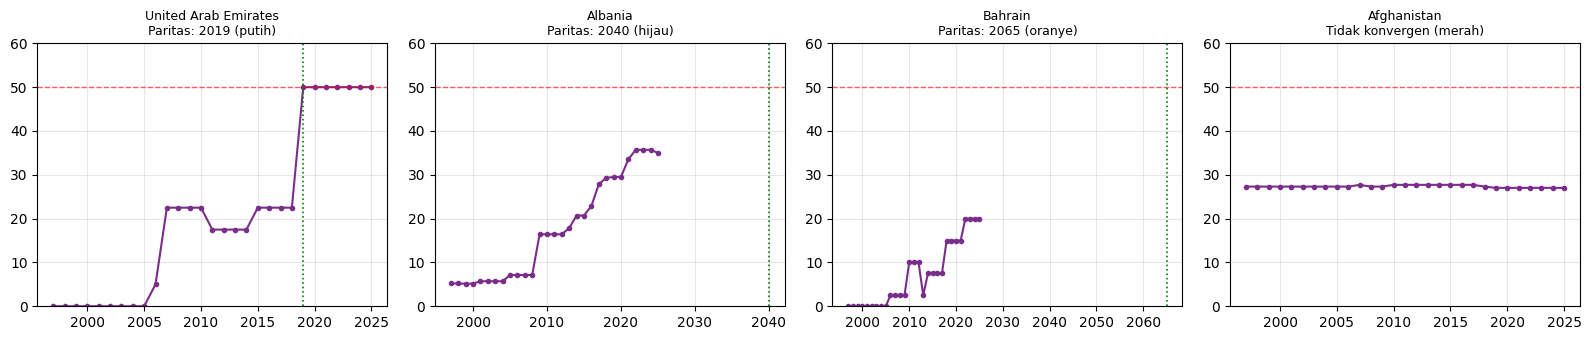

✅ Plot validasi disimpan: /content/drive/MyDrive/PetaKeheningan/output/forecast_sample_validation.png


In [ ]:
sample_countries = []
for cat in ['putih', 'hijau', 'oranye', 'merah']:
    ex = df_forecast[df_forecast['category'] == cat]['iso3'].head(1).tolist()
    sample_countries += ex

fig, axes = plt.subplots(1, len(sample_countries), figsize=(4 * len(sample_countries), 3.5))
if len(sample_countries) == 1:
    axes = [axes]

for ax, iso in zip(axes, sample_countries):
    grp  = df_panel[df_panel['iso3'] == iso].sort_values('year')
    info = df_forecast[df_forecast['iso3'] == iso].iloc[0]

    ax.plot(grp['year'], grp['pct_women'], color='#7B2D8B', marker='o', ms=3, label='Aktual')
    ax.axhline(50, color='red', ls='--', lw=1, alpha=0.6)

    if pd.notna(info['predicted_parity_year']):
        ax.axvline(info['predicted_parity_year'], color='green', ls=':', lw=1.2)
        ax.set_title(f"{info['country']}\nParitas: {int(info['predicted_parity_year'])} ({info['category']})", fontsize=9)
    else:
        ax.set_title(f"{info['country']}\nTidak konvergen ({info['category']})", fontsize=9)

    ax.set_ylim(0, 60)
    ax.grid(alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(OUTPUT_DIR, 'forecast_sample_validation.png')
plt.savefig(viz_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Plot validasi disimpan: {viz_path}")


### 8. Bonus — Insight Awal: Kuota Gender vs Kecepatan Pertumbuhan

Analisis cepat untuk menjawab pertanyaan penelitian #2: apakah negara dengan kuota gender menunjukkan tren peningkatan yang lebih cepat? (Korelasi sederhana, bukan causal inference.)

In [ ]:
def growth_slope(group):
    years  = group['year'].values
    series = group['pct_women'].values
    slope, _ = np.polyfit(years, series, 1)
    return slope

slopes = (
    df_panel.groupby('iso3')
    .apply(growth_slope)
    .rename('slope_pct_per_year')
    .reset_index()
)

quota_lookup = df_panel.drop_duplicates('iso3')[['iso3', 'quota_type']]
slopes = slopes.merge(quota_lookup, on='iso3', how='left')

print("📊 Rata-rata kecepatan pertumbuhan (poin persentase/tahun) per jenis kuota:")
print(slopes.groupby('quota_type')['slope_pct_per_year'].agg(['mean', 'median', 'count']).round(3).to_string())


📊 Rata-rata kecepatan pertumbuhan (poin persentase/tahun) per jenis kuota:
                             mean  median  count
quota_type                                      
Legislated Candidate Quota  0.723   0.687    106
No Quota                    0.414   0.431     53
Voluntary Party Quota       0.500   0.490     26


### 8.9 Gabungkan dengan Data Peta & Simpan ke Google Drive

In [ ]:
summary_path = os.path.join(OUTPUT_DIR, 'country_summary.csv')
df_summary   = pd.read_csv(summary_path)

df_map = df_summary.merge(
    df_forecast[['iso3', 'rmse', 'mae', 'model_order', 'predicted_parity_year', 'category', 'note']],
    on='iso3', how='left'
)

FORECAST_PATH = os.path.join(OUTPUT_DIR, 'forecast_results_arima.csv')
MAP_PATH      = os.path.join(OUTPUT_DIR, 'map_data_with_forecast.csv')

df_forecast.to_csv(FORECAST_PATH, index=False)
df_map.to_csv(MAP_PATH, index=False)

print("✅ Hasil forecasting disimpan ke Google Drive")
print(f"   {FORECAST_PATH}")
print(f"   {MAP_PATH}")
print()
print("File ini siap dipakai sebagai layer 'prediksi' di peta Folium/Streamlit:")
print("   - Warna choropleth      → kolom 'category' (hijau / oranye / merah / putih)")
print("   - Tooltip RMSE & MAE    → kolom 'rmse', 'mae'")
print("   - Popup tahun paritas   → kolom 'predicted_parity_year'")
print()
print("🎉 Tahap forecasting ARIMA selesai — siap lanjut ke pembangunan aplikasi Streamlit + Folium!")


✅ Hasil forecasting disimpan ke Google Drive
   /content/drive/MyDrive/PetaKeheningan/output/forecast_results_arima.csv
   /content/drive/MyDrive/PetaKeheningan/output/map_data_with_forecast.csv

File ini siap dipakai sebagai layer 'prediksi' di peta Folium/Streamlit:
   - Warna choropleth      → kolom 'category' (hijau / oranye / merah / putih)
   - Tooltip RMSE & MAE    → kolom 'rmse', 'mae'
   - Popup tahun paritas   → kolom 'predicted_parity_year'

🎉 Tahap forecasting ARIMA selesai — siap lanjut ke pembangunan aplikasi Streamlit + Folium!
